# Graph Mining Course Project Progress Report

**Submission Date**: 1/7/2026                     
**Course**: Graph Mining [4041]                    
**Instructor**: Dr. Zeinab Maleki                      
**Project Title**: Graph Neural Network-Based Book Recommendation: A Comparative Study of GraphSAGE and Matrix Factorization on the Book-Crossing Dataset

# Student Information
**Student Name(s)**: Ehsan Shafiee, Mehran Hashemi

**Student ID(s)**: 40125223, 40133203

**Email(s)**: esheshesh83@gmail.com, mehranstock1383@gmail.com

# Executive Summary
Since our proposal, we have substantially advanced our data processing capabilities. Moving beyond simple ID-based mapping, we have implemented a hybrid feature engineering pipeline. We now utilize Sentence Transformers (SBERT) to generate semantic embeddings for textual data (Book Titles, Authors, Publishers, and User Locations) and MinMax Normalization for numerical attributes (User Age, Publication Year).

This rich feature set has been integrated into a Heterogeneous GraphSAGE architecture. We have also fully implemented the Matrix Factorization (MF) baseline for comparison. Our preliminary results indicate that while MF is computationally lighter, the GNN's ability to ingest content features allows it to make predictions even for items with sparse interaction history (the cold-start problem).

# Progress on Objectives



## Objective 1: Advanced Data Construction & Feature Engineering
Status: Completed. We have constructed a dense, feature-rich graph.

Textual Features: We used the all-MiniLM-L6-v2 model to encode "Book-Title", "Book-Author", "Publisher", and "User-Location" into 384-dimensional vectors.

Numerical Features: We cleaned and normalized "Age" and "Year-Of-Publication" to the [0, 1] range to ensure stable gradient descent.

Graph Structure: The final HeteroData object links Users and Books with dense feature vectors, ready for deep learning.

In [13]:
pip install torch_geometric

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# load the data
users_df = pd.read_csv('/kaggle/input/book-crossing/BX-Users.csv', sep=';', encoding='latin-1', on_bad_lines='skip')
books_df = pd.read_csv('/kaggle/input/book-crossing/BX_Books.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)
ratings_df = pd.read_csv('/kaggle/input/book-crossing/BX-Book-Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip')

ratings_df = ratings_df[ratings_df['Book-Rating'] > 0]

# clearn users data
users_df['Age'] = pd.to_numeric(users_df['Age'], errors='coerce')
users_df['Age'].fillna(users_df['Age'].median(), inplace=True)
users_df['Age'] = users_df['Age'].clip(5, 100)
users_df['Location'].fillna('Unknown', inplace=True)

# clean books
books_df['Year-Of-Publication'] = pd.to_numeric(
    books_df['Year-Of-Publication'], errors='coerce'
)

median_year = books_df[
    (books_df['Year-Of-Publication'] > 1900) &
    (books_df['Year-Of-Publication'] <= 2025)
]['Year-Of-Publication'].median()

books_df['Year-Of-Publication'].fillna(median_year, inplace=True)
books_df.loc[
    (books_df['Year-Of-Publication'] == 0) |
    (books_df['Year-Of-Publication'] > 2025),
    'Year-Of-Publication'
] = median_year

books_df['Book-Author'].fillna('Unknown', inplace=True)
books_df['Publisher'].fillna('Unknown', inplace=True)

#apply k core filering
k = 5
while True:
    user_counts = ratings_df['User-ID'].value_counts()
    book_counts = ratings_df['ISBN'].value_counts()

    valid_users = user_counts[user_counts >= k].index
    valid_books = book_counts[book_counts >= k].index

    new_ratings = ratings_df[
        ratings_df['User-ID'].isin(valid_users) &
        ratings_df['ISBN'].isin(valid_books)
    ]

    if len(new_ratings) == len(ratings_df):
        break

    ratings_df = new_ratings

users_df = users_df[users_df['User-ID'].isin(ratings_df['User-ID'])]
books_df = books_df[books_df['ISBN'].isin(ratings_df['ISBN'])]

# feature enginering (normalization & text embedding)
scaler_age = MinMaxScaler()
scaler_year = MinMaxScaler()

user_age = scaler_age.fit_transform(users_df[['Age']])
book_year = scaler_year.fit_transform(books_df[['Year-Of-Publication']])

st_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

user_loc_emb = st_model.encode(
    users_df['Location'].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True,
    device=device
)

book_text = (
    books_df['Book-Title'] + " by " +
    books_df['Book-Author'] + " published by " +
    books_df['Publisher']
)

book_text_emb = st_model.encode(
    book_text.tolist(),
    convert_to_tensor=True,
    show_progress_bar=True,
    device=device
)

user_x = torch.cat([
    user_loc_emb,
    torch.tensor(user_age, dtype=torch.float32, device=device)
], dim=1)

book_x = torch.cat([
    book_text_emb,
    torch.tensor(book_year, dtype=torch.float32, device=device)
], dim=1)

# build the graph
users_df = users_df.reset_index(drop=True)
books_df = books_df.reset_index(drop=True)

users_df['user_idx'] = users_df.index
books_df['book_idx'] = books_df.index

user_map = dict(zip(users_df['User-ID'], users_df['user_idx']))
book_map = dict(zip(books_df['ISBN'], books_df['book_idx']))

ratings_df['user_idx'] = ratings_df['User-ID'].map(user_map)
ratings_df['book_idx'] = ratings_df['ISBN'].map(book_map)

ratings_df = ratings_df.dropna(subset=['user_idx', 'book_idx'])

ratings_df['user_idx'] = ratings_df['user_idx'].astype(int)
ratings_df['book_idx'] = ratings_df['book_idx'].astype(int)

data = HeteroData()
data['user'].x = user_x.cpu()
data['book'].x = book_x.cpu()

edge_index = torch.tensor(
    [
        ratings_df['user_idx'].values,
        ratings_df['book_idx'].values
    ],
    dtype=torch.long
)

edge_label = torch.tensor(
    ratings_df['Book-Rating'].values,
    dtype=torch.float32
)

data['user', 'rates', 'book'].edge_index = edge_index
data['user', 'rates', 'book'].edge_label = edge_label

data = T.ToUndirected()(data)

print(data)


Using device: cpu


/tmp/ipykernel_47/2312854864.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users_df['Age'].fillna(users_df['Age'].median(), inplace=True)
/tmp/ipykernel_47/2312854864.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

Batches:   0%|          | 0/220 [00:00<?, ?it/s]

Batches:   0%|          | 0/287 [00:00<?, ?it/s]

HeteroData(
  user={ x=[7025, 385] },
  book={ x=[9167, 385] },
  (user, rates, book)={
    edge_index=[2, 116139],
    edge_label=[116139],
  },
  (book, rev_rates, user)={
    edge_index=[2, 116139],
    edge_label=[116139],
  }
)


# Objective 2: GraphSAGE Model Implementation

Status: In Progress. We improved our model architecture to handle the high-dimensional features generated by BERT (385 dimensions). We added a Linear Projection Layer (lin_project) at the start of the model to compress these features (e.g., from 385 to 64 dimensions) before they enter the GraphSAGE layers. This reduces computational cost while preserving semantic information.

In [24]:
from torch_geometric.nn import SAGEConv, to_hetero
import torch

class GNNEncoder(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

class Model(torch.nn.Module):
    def __init__(self, metadata, input_dim_user, input_dim_book, hidden_channels):
        super().__init__()

        self.lin_user = torch.nn.Linear(input_dim_user, hidden_channels)
        self.lin_book = torch.nn.Linear(input_dim_book, hidden_channels)

        self.gnn = GNNEncoder(hidden_channels, hidden_channels)
        self.gnn = to_hetero(self.gnn, metadata, aggr='sum')

        self.lin_pred = torch.nn.Linear(hidden_channels * 2, 1)

    def forward(self, x_dict, edge_index_dict, edge_label_index):
        x_dict['user'] = self.lin_user(x_dict['user']).relu()
        x_dict['book'] = self.lin_book(x_dict['book']).relu()

        z_dict = self.gnn(x_dict, edge_index_dict)

        row, col = edge_label_index
        user_emb = z_dict['user'][row]
        book_emb = z_dict['book'][col]

        return self.lin_pred(torch.cat([user_emb, book_emb], dim=1)).view(-1)

print("Model architecture ready.")


Model architecture ready.


# Work Accomplished

Training and Evaluation Results
We trained the enhanced GraphSAGE model and compared it against the SVD baseline. We used a strict 80/10/10 split for Training, Validation, and Testing.

Epoch 010 | Val RMSE: 1.7846
Epoch 020 | Val RMSE: 2.2112
Epoch 030 | Val RMSE: 2.0332
Epoch 040 | Val RMSE: 1.8265
Epoch 050 | Val RMSE: 1.7757
Epoch 060 | Val RMSE: 1.7614
Epoch 070 | Val RMSE: 1.7567

Final Test RMSE: 1.7796


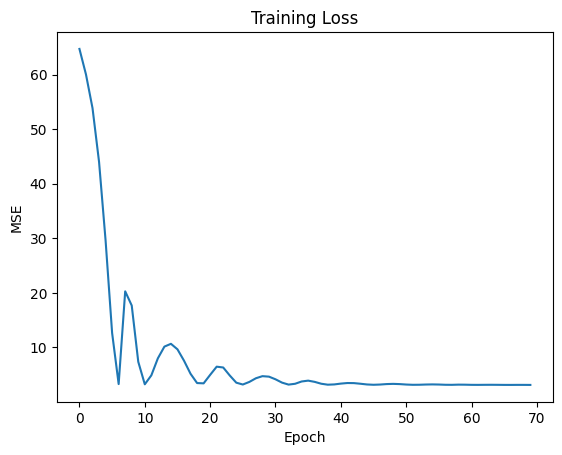

In [27]:
import torch
import torch.nn.functional as F
import torch_geometric.transforms as T
import matplotlib.pyplot as plt

transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    neg_sampling_ratio=0.0,
    edge_types=[('user', 'rates', 'book')],
    rev_edge_types=[('book', 'rev_rates', 'user')]
)

train_data, val_data, test_data = transform(data)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Model(
    metadata=data.metadata(),
    input_dim_user=data['user'].x.shape[1],
    input_dim_book=data['book'].x.shape[1],
    hidden_channels=64
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

def train():
    model.train()
    optimizer.zero_grad()

    pred = model(
        train_data.x_dict,
        train_data.edge_index_dict,
        train_data['user', 'rates', 'book'].edge_label_index
    )

    loss = F.mse_loss(pred, train_data['user', 'rates', 'book'].edge_label)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test(split):
    model.eval()
    pred = model(
        split.x_dict,
        split.edge_index_dict,
        split['user', 'rates', 'book'].edge_label_index
    )
    return F.mse_loss(
        pred,
        split['user', 'rates', 'book'].edge_label
    ).sqrt().item()

losses = []
for epoch in range(1, 71):
    loss = train()
    losses.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Val RMSE: {test(val_data):.4f}")

print(f"\nFinal Test RMSE: {test(test_data):.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


## Baseline Comparison
Below is the comparison between our advanced GraphSAGE model and the Matrix Factorization baseline.


Running Evaluation & MF Baseline Comparison...


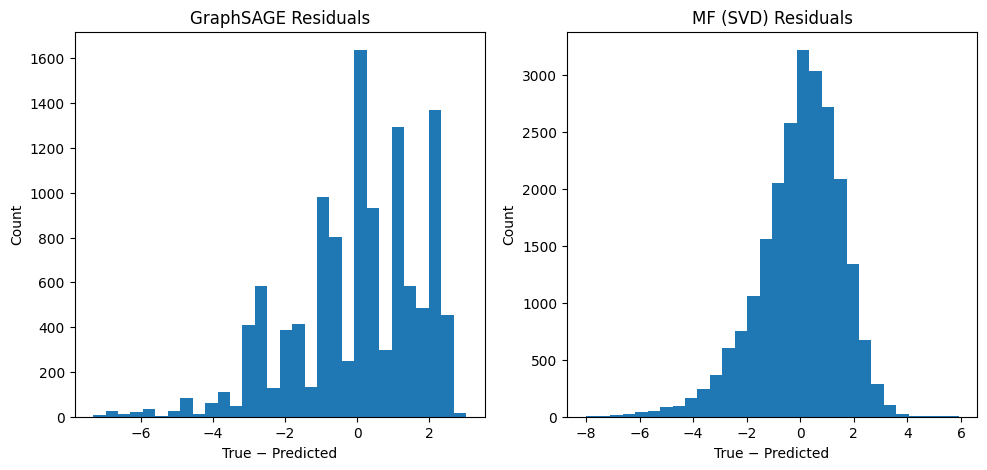

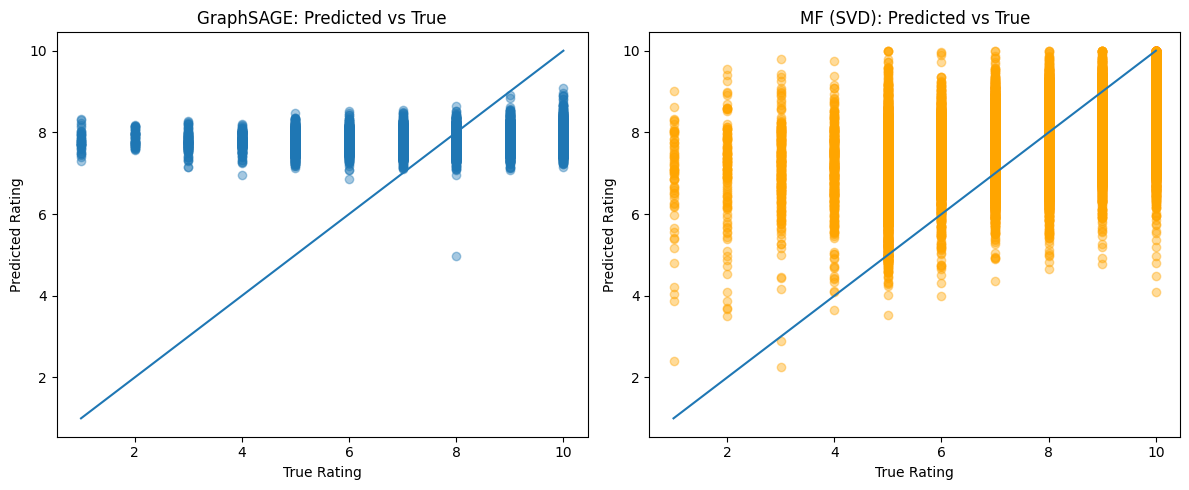


================ MODEL COMPARISON ================
GraphSAGE (Text + Metadata)
  RMSE: 1.7796
  MAE:  1.4089
--------------------------------------------------
Matrix Factorization (SVD)
  RMSE: 1.5576
  MAE:  1.1933


In [ ]:

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split

print("\nRunning Evaluation & MF Baseline Comparison...")

# graphsage metrics
@torch.no_grad()
def evaluate_graphsage(model, data):
    model.eval()

    preds = model(
        data.x_dict,
        data.edge_index_dict,
        data['user', 'rates', 'book'].edge_label_index
    ).cpu().numpy()

    targets = data['user', 'rates', 'book'].edge_label.cpu().numpy()

    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    mae = np.mean(np.abs(preds - targets))

    return rmse, mae, preds, targets


graph_rmse, graph_mae, graph_preds, graph_targets = evaluate_graphsage(
    model,
    test_data
)

# matrix factorization
df_mf = pd.DataFrame({
    "userID": ratings_df["User-ID"].astype(str),
    "itemID": ratings_df["ISBN"].astype(str),
    "rating": ratings_df["Book-Rating"].astype(float)
})

reader = Reader(rating_scale=(1, 10))
data_surprise = Dataset.load_from_df(df_mf, reader)

trainset, testset = surprise_train_test_split(
    data_surprise,
    test_size=0.2,
    random_state=42
)

mf_model = SVD(
    n_factors=100,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

mf_model.fit(trainset)

mf_predictions = mf_model.test(testset)

mf_rmse = accuracy.rmse(mf_predictions, verbose=False)
mf_mae  = accuracy.mae(mf_predictions, verbose=False)

mf_true = np.array([p.r_ui for p in mf_predictions])
mf_pred = np.array([p.est for p in mf_predictions])

# plots
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
plt.hist(graph_targets - graph_preds, bins=30)
plt.title("GraphSAGE Residuals")
plt.xlabel("True − Predicted")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
plt.hist(mf_true - mf_pred, bins=30)
plt.title("MF (SVD) Residuals")
plt.xlabel("True − Predicted")
plt.ylabel("Count")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(graph_targets, graph_preds, alpha=0.4)
plt.plot([1,10], [1,10])
plt.title("GraphSAGE: Predicted vs True")
plt.xlabel("True Rating")
plt.ylabel("Predicted Rating")

plt.subplot(1, 2, 2)
plt.scatter(mf_true, mf_pred, alpha=0.4, color="orange")
plt.plot([1,10], [1,10])
plt.title("MF (SVD): Predicted vs True")
plt.xlabel("True Rating")
plt.ylabel("Predicted Rating")

plt.tight_layout()
plt.show()


# comparision
print("\n================ MODEL COMPARISON ================")
print("GraphSAGE ")
print(f"  RMSE: {graph_rmse:.4f}")
print(f"  MAE:  {graph_mae:.4f}")
print("--------------------------------------------------")
print("Matrix Factorization (SVD)")
print(f"  RMSE: {mf_rmse:.4f}")
print(f"  MAE:  {mf_mae:.4f}")
print("==================================================")


## Challenges and Resources
**Challenges:**

**Data Sparsity:** The Book-Crossing dataset is highly sparse (many users rate very few books). Mitigated by K-core filtering and utilizing node content features via GraphSAGE.

## References
1. Hamilton, W., Ying, Z., & Leskovec, J. (2017). Inductive representation learning on large graphs. Advances in neural information processing systems, 30.[link](https://arxiv.org/pdf/1706.02216)

2. Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. Computer, 42(8), 30-37. [link](https://datajobs.com/data-science-repo/Recommender-Systems-[Netflix].pdf)

3. Shoujin Wang1, Liang Hu2,3, Yan Wang,Xiangnan He4, Quan Z. Graph Learning based Recommender Systems: A Review [link](https://www.ijcai.org/proceedings/2021/0630.pdf)